# Property transaction analysis

This notebook loads the `fact_transaction`, `dim_location`, and `dim_project` tables from BigQuery into pandas DataFrames, joins them by their dimension keys, and explores transaction trends.

## Setup

Install the required packages in the active notebook environment if needed:

```python
%pip install pandas matplotlib sqlalchemy sqlalchemy-bigquery
```

Authenticate with Google Application Default Credentials before running the queries (for example, `gcloud auth application-default login`). The authenticated account needs permission to run BigQuery jobs and read the `propery_trans1` dataset. No credentials are stored in this notebook.

In [1]:
%pip install sqlalchemy-bigquery

  Using cached sqlalchemy_bigquery-1.17.3-py3-none-any.whl.metadata (15 kB)
Using cached sqlalchemy_bigquery-1.17.3-py3-none-any.whl (41 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

PROJECT_ID = "ringed-griffin-509403-b4"
DATASET_ID = "propery_trans1"

# The BigQuery SQLAlchemy dialect uses Application Default Credentials.
engine = create_engine(f"bigquery://{PROJECT_ID}/{DATASET_ID}")

## Load the fact and dimension tables

The three source tables are kept as separate DataFrames, then linked with the warehouse keys: `project_key` and `location_key`.

In [2]:
def load_table(table_name: str) -> pd.DataFrame:
    query = text(f"SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.{table_name}`")
    with engine.connect() as connection:
        return pd.read_sql_query(query, connection)


fact_transaction_df = load_table("fact_transaction")
dim_location_df = load_table("dim_location")
dim_project_df = load_table("dim_project")

print(f"fact_transaction: {fact_transaction_df.shape}")
print(f"dim_location:     {dim_location_df.shape}")
print(f"dim_project:      {dim_project_df.shape}")
display(fact_transaction_df.head())
display(dim_location_df.head())
display(dim_project_df.head())

/home/jenho/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/client.py:626: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


fact_transaction: (170224, 16)
dim_location:     (153075, 7)
dim_project:      (2947, 6)


,transaction_key,project_key,location_key,sale_date,transacted_price,nett_price,area_sqft,area_sqm,unit_price_psf,new_trans_price,percentage_difference,unit_price_psm,number_of_units,type_of_sale,type_of_area,purchaser_address_indicator
0,3474790414281159860,-4852532521223715081,6021146233820805257,2020-11-06,8000000.0,NaN,5048.32,469.0,1585.0,8001587,0.000198,17058.0,1,RESALE,STRATA,PRIVATE
1,5619611621151717454,754663682913641818,-5508014609348575077,2016-03-10,680000.0,NaN,1119.46,104.0,607.0,679512,-0.000718,6538.0,1,RESALE,STRATA,PRIVATE
2,2270959200694403351,6030734890887807752,5114548285489408306,2021-11-15,700000.0,NaN,1119.46,104.0,625.0,699663,-0.000483,6731.0,1,RESALE,STRATA,HDB
3,911406479674455196,754663682913641818,7947363692064715591,2015-05-22,730000.0,NaN,1119.46,104.0,652.0,729888,-0.000153,7019.0,1,RESALE,STRATA,PRIVATE
4,6204921242229294112,754663682913641818,-249969701356554278,2013-08-02,735000.0,NaN,1119.46,104.0,657.0,735485,0.000660,7067.0,1,RESALE,STRATA,HDB


,location_key,address,postal_code,postal_district,postal_sector,planning_region,planning_area
0,-4475777105292551953,8 ANG MO KIO AVENUE 2 #13-02,567695,20,56,NORTH EAST REGION,ANG MO KIO
1,-9070103537064985156,8 ANG MO KIO AVENUE 2 #15-02,567695,20,56,NORTH EAST REGION,ANG MO KIO
2,2931376671938048836,8 ANG MO KIO AVENUE 2 #01-05,567695,20,56,NORTH EAST REGION,ANG MO KIO
3,-4675656113956014533,8 ANG MO KIO AVENUE 2 #08-06,567695,20,56,NORTH EAST REGION,ANG MO KIO
4,1536598111544684039,8 ANG MO KIO AVENUE 2 #16-01,567695,20,56,NORTH EAST REGION,ANG MO KIO


,project_key,project_name,property_type,tenure,completion_year,completion_status
0,-659395514409916962,N.A.,APARTMENT,9999 YRS FROM 01/01/1957,NaN,UNKNOWN
1,-8495981504839932944,LION TOWERS,APARTMENT,FREEHOLD,NaN,UNKNOWN
2,6407162192931709703,CAIRNHILL NINE,APARTMENT,99 YRS FROM 12/05/2014,NaN,UNCOMPLETED
3,-1625539464995052450,LOFT@HOLLAND,APARTMENT,FREEHOLD,NaN,UNCOMPLETED
4,5205085911062157091,IKIGAI,APARTMENT,FREEHOLD,NaN,UNCOMPLETED


In [3]:
project_columns = dim_project_df[["project_key", "project_name"]]
location_columns = dim_location_df[["location_key", "planning_region"]]

transactions_df = (
    fact_transaction_df
    .merge(project_columns, on="project_key", how="left", validate="many_to_one")
    .merge(location_columns, on="location_key", how="left", validate="many_to_one")
)

print(f"Joined transactions: {transactions_df.shape}")
display(transactions_df[[
    "transaction_key", "sale_date", "unit_price_psf", "project_name", "planning_region"
]].head())

Joined transactions: (170224, 18)


,transaction_key,sale_date,unit_price_psf,project_name,planning_region
0,3474790414281159860,2020-11-06,1585.0,TANGLIN RESIDENCES,CENTRAL REGION
1,5619611621151717454,2016-03-10,607.0,PARK VIEW MANSION,WEST REGION
2,2270959200694403351,2021-11-15,625.0,PEOPLE'S PARK COMPLEX,CENTRAL REGION
3,911406479674455196,2015-05-22,652.0,PARK VIEW MANSION,WEST REGION
4,6204921242229294112,2013-08-02,657.0,PARK VIEW MANSION,WEST REGION


## Unit price and transaction volume over time

Monthly average `unit_price_psf` is calculated over rows with a valid price. Transaction volume is the number of fact rows per month (one row per source transaction), independent of whether its price is present.

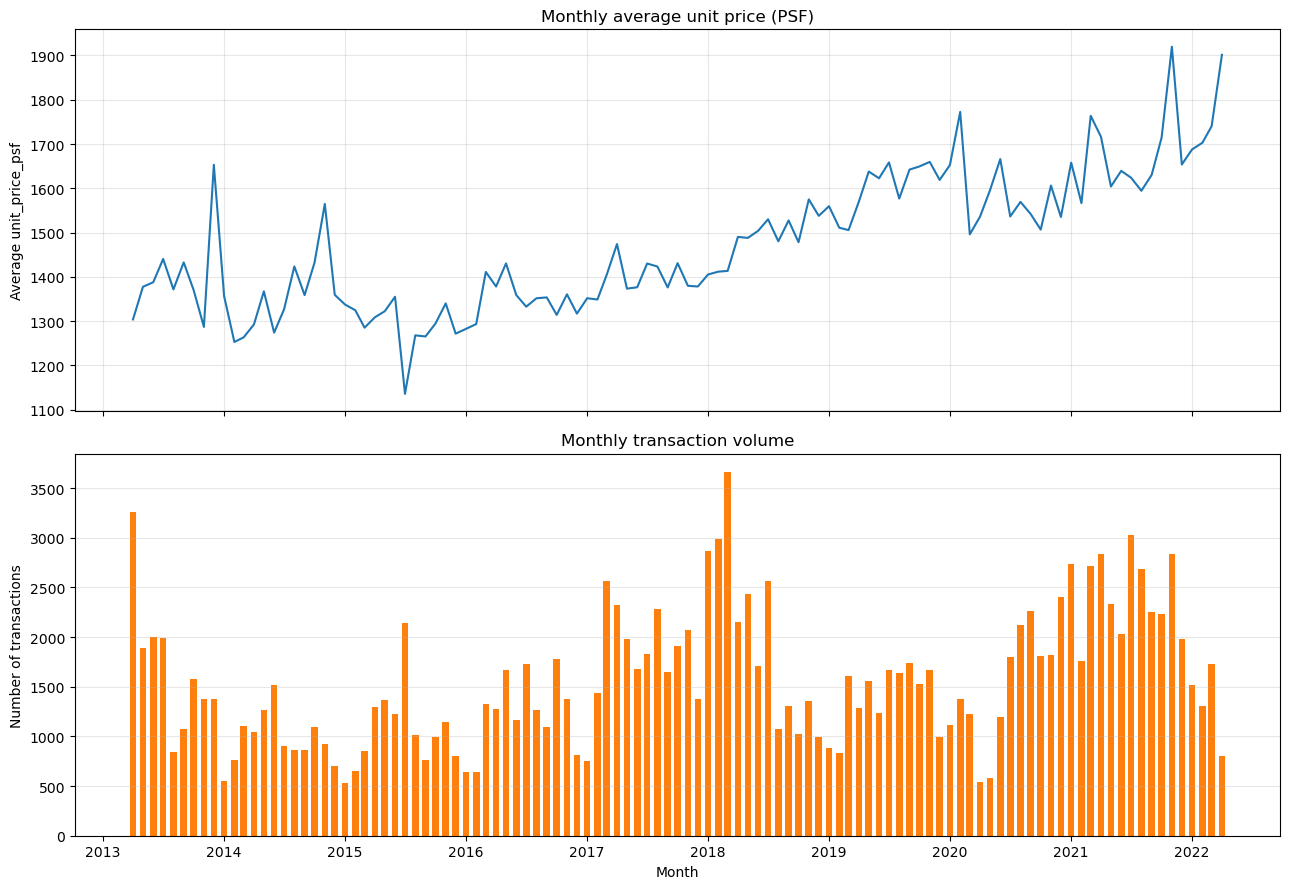

,month,average_unit_price_psf,transaction_volume
97,2021-05-01,1604.056959,2335
98,2021-06-01,1639.496307,2031
99,2021-07-01,1623.825512,3026
100,2021-08-01,1594.513785,2684
101,2021-09-01,1630.517960,2255
102,2021-10-01,1714.785202,2230
103,2021-11-01,1919.856287,2839
104,2021-12-01,1653.827604,1978
105,2022-01-01,1687.922976,1519
106,2022-02-01,1702.888294,1307


In [4]:
transactions_df["sale_date"] = pd.to_datetime(transactions_df["sale_date"], errors="coerce")
transactions_df["unit_price_psf"] = pd.to_numeric(
    transactions_df["unit_price_psf"], errors="coerce"
)

dated_transactions = transactions_df.dropna(subset=["sale_date"]).copy()
dated_transactions["month"] = dated_transactions["sale_date"].dt.to_period("M").dt.to_timestamp()

monthly_trends = (
    dated_transactions.groupby("month")
    .agg(
        average_unit_price_psf=("unit_price_psf", "mean"),
        transaction_volume=("transaction_key", "count"),
    )
    .reset_index()
    .sort_values("month")
)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
axes[0].plot(monthly_trends["month"], monthly_trends["average_unit_price_psf"], color="tab:blue")
axes[0].set_title("Monthly average unit price (PSF)")
axes[0].set_ylabel("Average unit_price_psf")
axes[0].grid(True, alpha=0.3)

axes[1].bar(monthly_trends["month"], monthly_trends["transaction_volume"], color="tab:orange", width=20)
axes[1].set_title("Monthly transaction volume")
axes[1].set_ylabel("Number of transactions")
axes[1].set_xlabel("Month")
axes[1].grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

display(monthly_trends.tail(12))

## Top 10 projects by transaction count

Projects are ranked by the number of fact transactions associated with each project. Rows without a matching project name are excluded.

,project_name,transaction_count
2193,TREASURE AT TAMPINES,2208
1203,NORMANTON PARK,1753
759,HIGH PARK RESIDENCES,1704
1490,RIVERFRONT RESIDENCES,1483
1311,PARC ESTA,1406
1308,PARC CLEMATIS,1380
924,KINGSFORD WATERBAY,1364
1932,THE FLORENCE RESIDENCES,1347
1711,STIRLING RESIDENCES,1273
2111,THE TAPESTRY,1214


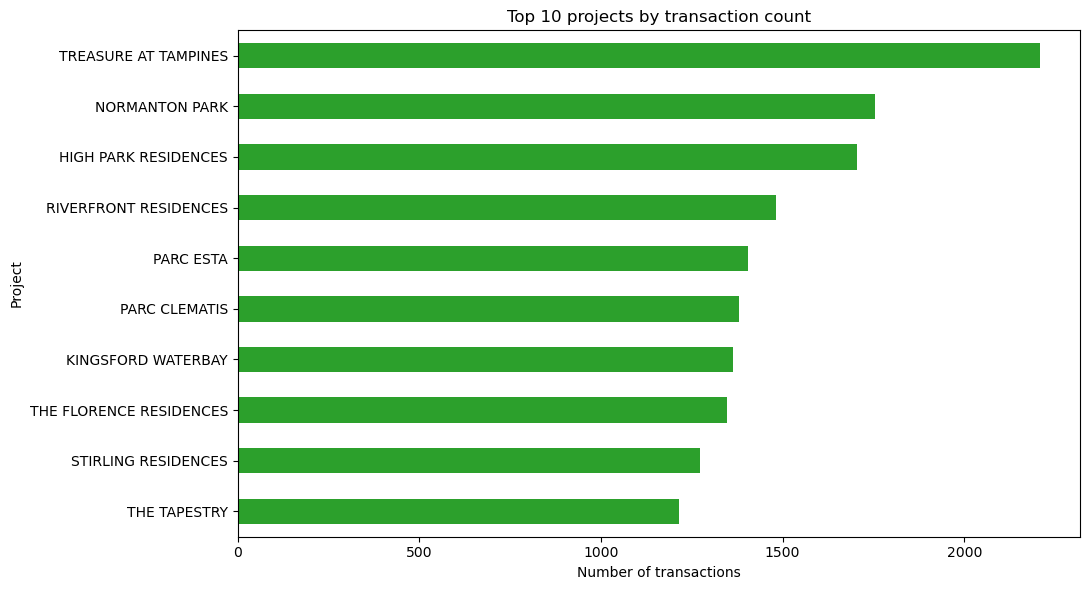

In [5]:
top_10_projects = (
    transactions_df.dropna(subset=["project_name"])
    .groupby("project_name")
    .agg(transaction_count=("transaction_key", "count"))
    .reset_index()
    .sort_values(["transaction_count", "project_name"], ascending=[False, True])
    .head(10)
)

display(top_10_projects)
top_10_projects.sort_values("transaction_count").plot.barh(
    x="project_name", y="transaction_count", legend=False, figsize=(11, 6), color="tab:green"
)
plt.title("Top 10 projects by transaction count")
plt.xlabel("Number of transactions")
plt.ylabel("Project")
plt.tight_layout()
plt.show()

## Average unit price by planning region

The regional average uses non-null `unit_price_psf` values. The transaction count is included to provide context for each average.

,planning_region,median_unit_price_psf,transaction_count
0,CENTRAL REGION,1689.0,86110
4,WEST REGION,1286.0,22484
2,NORTH EAST REGION,1239.0,26402
1,EAST REGION,1121.0,29235
3,NORTH REGION,1065.0,5993


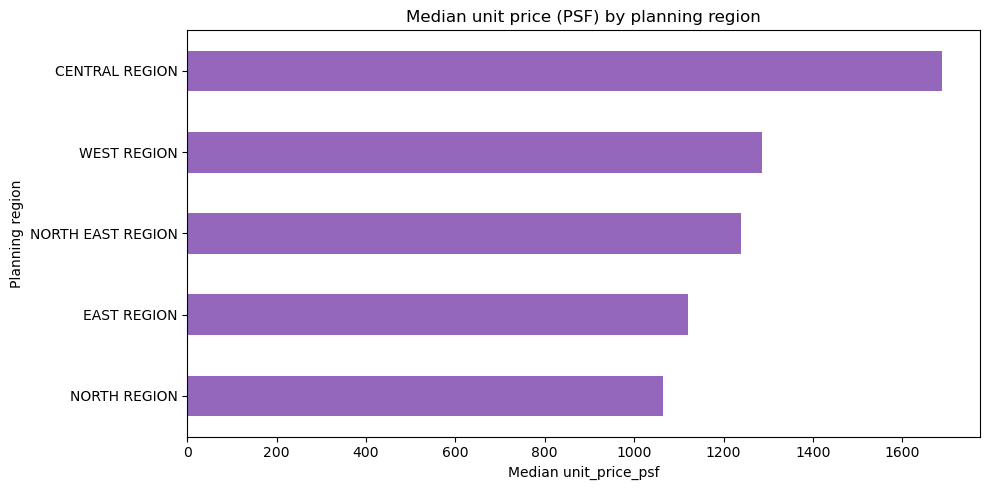

In [6]:
median_price_by_region = (
    transactions_df.dropna(subset=["planning_region", "unit_price_psf"])
    .groupby("planning_region")
    .agg(
        median_unit_price_psf=("unit_price_psf", "median"),
        transaction_count=("transaction_key", "count"),
    )
    .reset_index()
    .sort_values("median_unit_price_psf", ascending=False)
)

display(median_price_by_region)
median_price_by_region.sort_values("median_unit_price_psf").plot.barh(
    x="planning_region", y="median_unit_price_psf", legend=False, figsize=(10, 5), color="tab:purple"
)
plt.title("Median unit price (PSF) by planning region")
plt.xlabel("Median unit_price_psf")
plt.ylabel("Planning region")
plt.tight_layout()
plt.show()

## Purchaser group buying differences

Compare transaction volume, median purchase price, price per square foot, and property size across the groups recorded in `purchaser_address_indicator` (such as HDB and PRIVATE). The sale-type breakdown adds context about what each group bought. Medians reduce the influence of unusually high-value transactions; these descriptive comparisons do not establish why the groups differ.

,purchaser_address_indicator,transaction_count,median_purchase_price,median_unit_price_psf,median_area_sqft,transaction_share_pct
2,PRIVATE,88914,1420000.0,1452.0,1054.87,52.2
1,N.A,12782,1348000.0,1685.5,775.01,7.5
0,HDB,68528,1100800.0,1327.0,882.65,40.3


type_of_sale,NEW SALE,RESALE,SUB SALE
purchaser_address_indicator,,,
HDB,53.9,43.0,3.1
N.A,97.1,2.9,0.0
PRIVATE,39.8,58.1,2.1


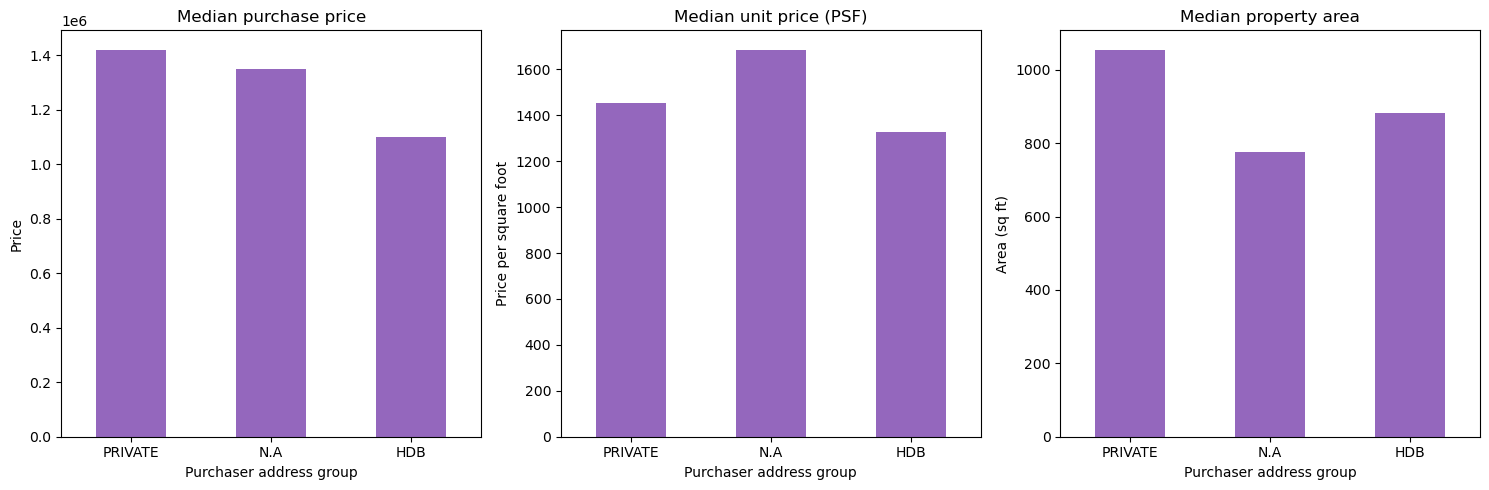

In [7]:
purchaser_transactions = transactions_df.copy()
purchaser_transactions["purchaser_address_indicator"] = (
    purchaser_transactions["purchaser_address_indicator"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace("", pd.NA)
)

for column in ["transacted_price", "unit_price_psf", "area_sqft"]:
    purchaser_transactions[column] = pd.to_numeric(purchaser_transactions[column], errors="coerce")

purchaser_comparison = purchaser_transactions.dropna(
    subset=["purchaser_address_indicator"]
).groupby("purchaser_address_indicator").agg(
    transaction_count=("transaction_key", "count"),
    median_purchase_price=("transacted_price", "median"),
    median_unit_price_psf=("unit_price_psf", "median"),
    median_area_sqft=("area_sqft", "median"),
).reset_index()
purchaser_comparison["transaction_share_pct"] = (
    purchaser_comparison["transaction_count"]
    / purchaser_comparison["transaction_count"].sum()
    * 100
).round(1)
purchaser_comparison = purchaser_comparison.sort_values(
    "median_purchase_price", ascending=False
)

display(purchaser_comparison)

sale_type_mix = pd.crosstab(
    purchaser_transactions["purchaser_address_indicator"],
    purchaser_transactions["type_of_sale"],
    normalize="index",
).mul(100).round(1)
sale_type_mix.index.name = "purchaser_address_indicator"
display(sale_type_mix)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_metrics = [
    ("median_purchase_price", "Median purchase price", "Price"),
    ("median_unit_price_psf", "Median unit price (PSF)", "Price per square foot"),
    ("median_area_sqft", "Median property area", "Area (sq ft)"),
]
for ax, (metric, title, ylabel) in zip(axes, plot_metrics):
    purchaser_comparison.plot.bar(
        x="purchaser_address_indicator", y=metric, ax=ax, legend=False, color="tab:purple"
    )
    ax.set_title(title)
    ax.set_xlabel("Purchaser address group")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

In [9]:
engine.dispose()